In [1]:
# Code cell
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import omicverse as ov

# 路径与文件
DATA_ROOT = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation/Merge"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)
IN_PATH   = os.path.join(DATA_ROOT, "06_annotation/L1/L1_lineage_annotated.h5ad")
OUT_H5AD  = os.path.join(ANNO_DIR, "L3_annotated.h5ad")

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 读取L1注释后得到的完成细胞对象

In [2]:
adata = sc.read_h5ad(IN_PATH)
adata

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'GSM', 'group', 'GSE', 'leiden_scVI_0.2', 'L1lin_marker', 'L1lin_score', 'L1lin_gpt', 'L1_lineage', 'L1lin_conf'
    var: 'mt'
    uns: 'GSE_colors', 'L1_lineage_colors', 'REFERENCE_MANU', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities'

## 清理 AnnData 对象

In [3]:
# 定义你想删除的列名列表
# 这里的列名是根据你提供的信息推测的，请根据实际情况增减
obs_to_remove = [
    'L1lin_marker',     # 如果不再需要查看具体的marker依据
    'L1lin_score',      # 如果你接受了最终结果，通常不需要保留分数
    'L1lin_gpt',        # GPT生成的中间文本或标记
    'L1lin_conf'        # 置信度区间（除非你需要保留它做后续质控）
]

# 循环删除
for col in obs_to_remove:
    if col in adata.obs.columns:
        del adata.obs[col]
        print(f"已删除 obs 列: {col}")

# 查看清理后的 obs 列
print("剩余 obs 列:", adata.obs.columns.tolist())

已删除 obs 列: L1lin_marker
已删除 obs 列: L1lin_score
已删除 obs 列: L1lin_gpt
已删除 obs 列: L1lin_conf
剩余 obs 列: ['GSM', 'group', 'GSE', 'leiden_scVI_0.2', 'L1_lineage']


In [4]:
# 定义你想删除的 uns 键
uns_to_remove = [
    'rank_genes_groups',      # 差异分析结果通常很大，不需要存档时建议删除
    'L1lin_score_colors'      # 如果存在相关的颜色配置
]

for key in uns_to_remove:
    if key in adata.uns.keys():
        del adata.uns[key]
        print(f"已删除 uns 键: {key}")

已删除 uns 键: rank_genes_groups


## 将L3注释合并到对象当中

In [6]:
import pandas as pd

# 1. 定义 CSV 文件路径
csv_path = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/Merge/L3_annotation.csv"

# 2. 读取 CSV 文件
# index_col=0 表示将第一列（通常是 Barcode/Unnamed: 0）作为 DataFrame 的索引
annotation_df = pd.read_csv(csv_path, index_col=0)

# 检查一下读取是否正确，确保 index 是您的细胞 barcodes
print("CSV 前几行预览：")
print(annotation_df.head())

CSV 前几行预览：
                                    GSM        GSE group            L3
Unnamed: 0                                                            
GSM8980878_UC68_CELL478_N2   GSM8980878  GSE296969    UC       Naive T
GSM8980878_UC68_CELL572_N2   GSM8980878  GSE296969    UC      T_Stress
GSM8980878_UC68_CELL1670_N2  GSM8980878  GSE296969    UC   CD4+ Memory
GSM8980878_UC68_CELL2132_N1  GSM8980878  GSE296969    UC      CD8+ Tem
GSM8980878_UC68_CELL4295_N2  GSM8980878  GSE296969    UC  Contaminants


In [7]:
# 3. 提取您需要的 'L3' 列
# 这样可以防止把 CSV 里其他的列（如 GSM, group）重复合并进 adata
l3_series = annotation_df['L3']

# 4. 将 L3 列合并到 adata.obs 中
# 使用 join 或直接赋值都可以，Pandas 会根据 index (barcode) 自动对齐
# how='left' 保证以 adata 为主，如果 CSV 里缺少某些细胞，对应位置会填 NaN，不会报错
adata.obs = adata.obs.join(l3_series, how='left')

# 或者使用更简单的方式（如果确定没有重复列名）：
# adata.obs['L3'] = annotation_df['L3'] 
# (注意：这种直接赋值方式，如果 annotation_df 包含 adata 中没有的细胞，那些细胞会被忽略；
#  如果 adata 中有 annotation_df 没有的细胞，对应值会变成 NaN)

# 5. 检查合并结果
print("\n合并后 adata.obs 的列名：")
print(adata.obs.columns)

print("\n合并后 L3 列的前几行：")
print(adata.obs['L3'].head())

# 6. (可选) 检查是否有未匹配到的细胞 (NaN)
na_count = adata.obs['L3'].isna().sum()
print(f"\n未匹配到 L3 注释的细胞数量:{na_count}")


合并后 adata.obs 的列名：
Index(['GSM', 'group', 'GSE', 'leiden_scVI_0.2', 'L1_lineage', 'L3'], dtype='object')

合并后 L3 列的前几行：
GSM8980878_UC68_CELL6_N4     Contaminants
GSM8980878_UC68_CELL10_N2     Active_Glia
GSM8980878_UC68_CELL14_N2    Contaminants
GSM8980878_UC68_CELL20_N5    Contaminants
GSM8980878_UC68_CELL21_N3    Contaminants
Name: L3, dtype: object

未匹配到 L3 注释的细胞数量:0


In [8]:
adata

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'GSM', 'group', 'GSE', 'leiden_scVI_0.2', 'L1_lineage', 'L3'
    var: 'mt'
    uns: 'GSE_colors', 'L1_lineage_colors', 'REFERENCE_MANU', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities'

In [9]:
adata.obs["L3"].value_counts()

L3
Contaminants               40798
Early_Absorptive           29774
Plasma IgA                 25079
Inflammatory Fibro         24595
Low Quality                21789
Villus-top Fibro           21394
Absorptive                 21075
Plasma Stressed            20401
Crypt-bottom Fibro         17170
T_Stress                   13019
CD4+ Memory                12068
CD8+ Tem                   11008
Plasma IgG                 10942
Naive T                     8704
CD8+ Teff                   8612
Stem_TA_prolif              7424
Treg                        7340
Myofibroblasts              6836
Naive B                     6565
Active_Glia                 5950
Goblet                      5683
Tex                         5419
CD8+ Trm                    4580
B_Stress                    4466
Visceral SMCs               4074
Pericytes                   4014
NK                          3485
Activated Pericytes         3257
Mast                        2569
GC B                        2504
Inflamm

## 细胞过滤
去除Contaminants 和 Low Quality

In [10]:
# 1. 定义需要剔除的细胞类型
exclude_types = ['Contaminants', 'Low Quality']

# 2. 执行筛选
# 逻辑解读：保留那些 'L3' 列的值【不在 (~)】 exclude_types 列表中的细胞
# 注意：一定要加 .copy()，将视图(View)转换为实际的对象，避免后续分析报错
adata = adata[~adata.obs['L3'].isin(exclude_types)].copy()

# 3. 清理废弃的类别缓存 (重要！)
# 如果 L3 是 categorical 类型，即使删除了细胞，'Contaminants' 仍会记录在分类列表中
# 这一步可以确保画图时，图例中不再出现这两个已删除的类型
if adata.obs['L3'].dtype.name == 'category':
    adata.obs['L3'] = adata.obs['L3'].cat.remove_unused_categories()

# 4. 检查结果
print(f"筛选后的细胞数量: {adata.n_obs}")
print("当前 L3 包含的类别:", adata.obs['L3'].unique().tolist())

筛选后的细胞数量: 311920
当前 L3 包含的类别: ['Active_Glia', 'Villus-top Fibro', 'Inflammatory Fibro', 'Pericytes', 'Vascular SMCs', 'Crypt-bottom Fibro', 'Visceral SMCs', 'Capillary ECs', 'Activated Pericytes', 'Naive T', 'Cycling Fibroblasts', 'T_Stress', 'Plasma IgA', 'Naive B', 'B_Stress', 'Inflammatory SMCs', 'CD4+ Memory', 'CD8+ Tem', 'Plasma Stressed', 'Mac Activated', 'Mast', 'NK', 'Arterial ECs', 'Glia', 'Inflammatory Homing ECs', 'Treg', 'GC B', 'CD8+ Teff', 'Mac Inflammatory', 'Myofibroblasts', 'Tex', 'Plasma IgG', 'Mac Resident', 'Early_Absorptive', 'CD8+ Trm', 'pDC', 'Mono Classical', 'Mac Remodeling', 'DC Mature', 'Prolif Myeloid', 'Absorptive', 'Stem_TA_prolif', 'Goblet', 'Tuft']


In [ ]:
adata.obs["L3"].value_counts()

L3
Early_Absorptive           29774
Plasma IgA                 25079
Inflammatory Fibro         24595
Villus-top Fibro           21394
Absorptive                 21075
Plasma Stressed            20401
Crypt-bottom Fibro         17170
T_Stress                   13019
CD4+ Memory                12068
CD8+ Tem                   11008
Plasma IgG                 10942
Naive T                     8704
CD8+ Teff                   8612
Stem_TA_prolif              7424
Treg                        7340
Myofibroblasts              6836
Naive B                     6565
Active_Glia                 5950
Goblet                      5683
Tex                         5419
CD8+ Trm                    4580
B_Stress                    4466
Visceral SMCs               4074
Pericytes                   4014
NK                          3485
Activated Pericytes         3257
Mast                        2569
GC B                        2504
Inflammatory SMCs           2400
Arterial ECs                2329
Glia   

In [38]:
print(adata.obs["L3"].value_counts())

L3
Early_Absorptive           29774
Plasma IgA                 25079
Inflammatory Fibro         24595
Villus-top Fibro           21394
Absorptive                 21075
Plasma Stressed            20401
Crypt-bottom Fibro         17170
T_Stress                   13019
CD4+ Memory                12068
CD8+ Tem                   11008
Plasma IgG                 10942
Naive T                     8704
CD8+ Teff                   8612
Stem_TA_prolif              7424
Treg                        7340
Myofibroblasts              6836
Naive B                     6565
Active_Glia                 5950
Goblet                      5683
Tex                         5419
CD8+ Trm                    4580
B_Stress                    4466
Visceral SMCs               4074
Pericytes                   4014
NK                          3485
Activated Pericytes         3257
Mast                        2569
GC B                        2504
Inflammatory SMCs           2400
Arterial ECs                2329
Glia   

### 最终细胞数量及注释结果
- 311920个细胞
- 44种细胞类型

## 保存结果

In [12]:
adata.write_h5ad(OUT_H5AD, compression="gzip")

## 可视化

### 优化

In [14]:
adata

AnnData object with n_obs × n_vars = 311920 × 11743
    obs: 'GSM', 'group', 'GSE', 'leiden_scVI_0.2', 'L1_lineage', 'L3'
    var: 'mt'
    uns: 'GSE_colors', 'L1_lineage_colors', 'REFERENCE_MANU', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'umap', 'L3_colors'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities'

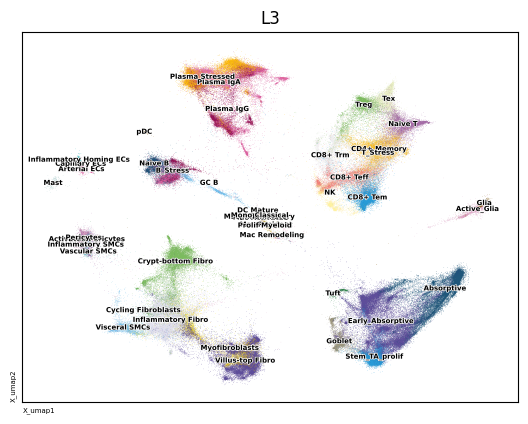

In [28]:
#粗略可视化
ov.pl.embedding(adata,
                basis='X_umap',
                color='L3',
                frameon='samll',
                legend_loc='on data',
                legend_fontoutline=1,
                legend_fontsize=5,
                palette=ov.utils.palette())

In [50]:
celltype_color = {
    # ==========================================
    # 1. 浆细胞 (Plasma) - 强化对比：深红 vs 鲜橙
    # ==========================================
    # 以前太接近，现在拉开色相
    'Plasma IgA':           '#C62828',  # 宝石红 (深沉，强调主群)
    'Plasma IgG':           '#FF6D00',  # 柿子橙 (鲜亮，与红色形成强烈反差)
    'Plasma Stressed':      '#FFAB91',  # 浅肉红 (柔和，表示状态)

    # ==========================================
    # 2. T细胞 & NK (T/NK) - 强化对比：墨绿 vs 莱姆 vs 孔雀蓝
    # ==========================================
    # 以前是渐变绿，现在加入色相偏移
    'CD8+ Teff':            '#1B5E20',  # 极深绿 (功能性强)
    'CD8+ Tem':             '#2E7D32',  # 森林绿
    'CD8+ Trm':             '#00695C',  # 蓝绿色 (定居记忆，偏冷)
    'CD4+ Memory':          '#43A047',  # 中草绿
    'Naive T':              '#81C784',  # 浅绿
    'Treg':                 '#CDDC39',  # 莱姆黄绿 (极具辨识度，一眼识别Treg)
    'T_Stress':             '#DCEDC8',  # 苍白绿
    'Tex':                  '#AED581',  # 灰黄绿
    'NK':                   '#00BCD4',  # 青色/孔雀蓝 (从绿色中跳脱出来，独立显示)

    # ==========================================
    # 3. B细胞 (B Cells) - 保持紫罗兰色系
    # ==========================================
    # 既然满意这个色系，保持不变，作为冷暖过渡
    'Naive B':              '#B39DDB',  # 浅薰衣草
    'GC B':                 '#7B1FA2',  # 深紫 (生发中心)
    'B_Stress':             '#BA68C8',  # 兰花紫

    # ==========================================
    # 4. 内皮细胞 (Endothelial) - 改为：青黛/松石色系
    # ==========================================
    # 【修改重点】完全避开紫色，使用蓝绿色调，代表血管
    'Arterial ECs':         '#006064',  # 深青色 (动脉)
    'Capillary ECs':        '#0097A7',  # 湖蓝色 (毛细血管)
    'Inflammatory Homing ECs':'#4DD0E1', # 亮青色
    # 这种颜色在红色(浆细胞)和紫色(B细胞)旁边非常显眼，不会混淆

    # ==========================================
    # 5. 成纤维/基质 (Fibroblasts) - 改为：暖粉/珊瑚色系
    # ==========================================
    # 【修改重点】去除褐色，改为温暖、干净的结缔组织色
    'Crypt-bottom Fibro':   '#D81B60',  # 胭脂红 (基底)
    'Villus-top Fibro':     '#F06292',  # 亮粉色 (顶部)
    'Inflammatory Fibro':   '#E91E63',  # 玫瑰红 (炎症)
    'Myofibroblasts':       '#F48FB1',  # 柔粉色 (肌成纤维)
    'Cycling Fibroblasts':  '#F8BBD0',  # 浅粉 (增殖)
    
    # --- 平滑肌 (SMCs) --- 
    # 搭配珊瑚色，保持暖色调但不脏
    'Visceral SMCs':        "#901F19",  # 深栗褐 (Very Dark Brown-Red)
    'Vascular SMCs':        '#8D6E63',  # 栗色 (Chestnut)
    'Inflammatory SMCs':    '#A1887F',  # 灰褐红
    'Pericytes':            '#3E2723',  # 极深咖 (Almost Black-Brown)
    'Activated Pericytes':  '#795548',  # 可可褐

    # ==========================================
    # 6. 上皮谱系 (Epithelial) - 经典纯蓝系
    # ==========================================
    'Absorptive':           '#1565C0',  # 皇室蓝
    'Early_Absorptive':     '#42A5F5',  # 天蓝
    'Stem_TA_prolif':       '#90CAF9',  # 浅蓝
    'Goblet':               '#3F51B5',  # 靛青
    'Tuft':                 '#0288D1',  # 海洋蓝

    # ==========================================
    # 7. 髓系 (Myeloid) - 金黄/琥珀色系 (保持不变)
    # ==========================================
    'Mono Classical':       '#FFF59D',  # 柠檬黄
    'Mac Resident':         '#FBC02D',  # 金黄
    'Mac Inflammatory':     '#FF6F00',  # 琥珀色 (偏深)
    'Mac Activated':        '#FFB300',  # 橘黄
    'Mac Remodeling':       '#FFCA28',  # 蛋黄
    'Prolif Myeloid':       '#FFF9C4',  # 奶酪黄
    'DC Mature':            '#FFCC80',  # 浅杏色
    'pDC':                  '#E6EE9C',  # 酸橙色 (区分度高)
    'Mast':                 '#795548',  # 此时用褐色给肥大细胞，作为离群点很合适

    # ==========================================
    # 8. 神经 (Neural) - 极致冷灰
    # ==========================================
    'Glia':                 '#90A4AE',  # 蓝灰
    'Active_Glia':          '#546E7A',  # 深板岩灰
}

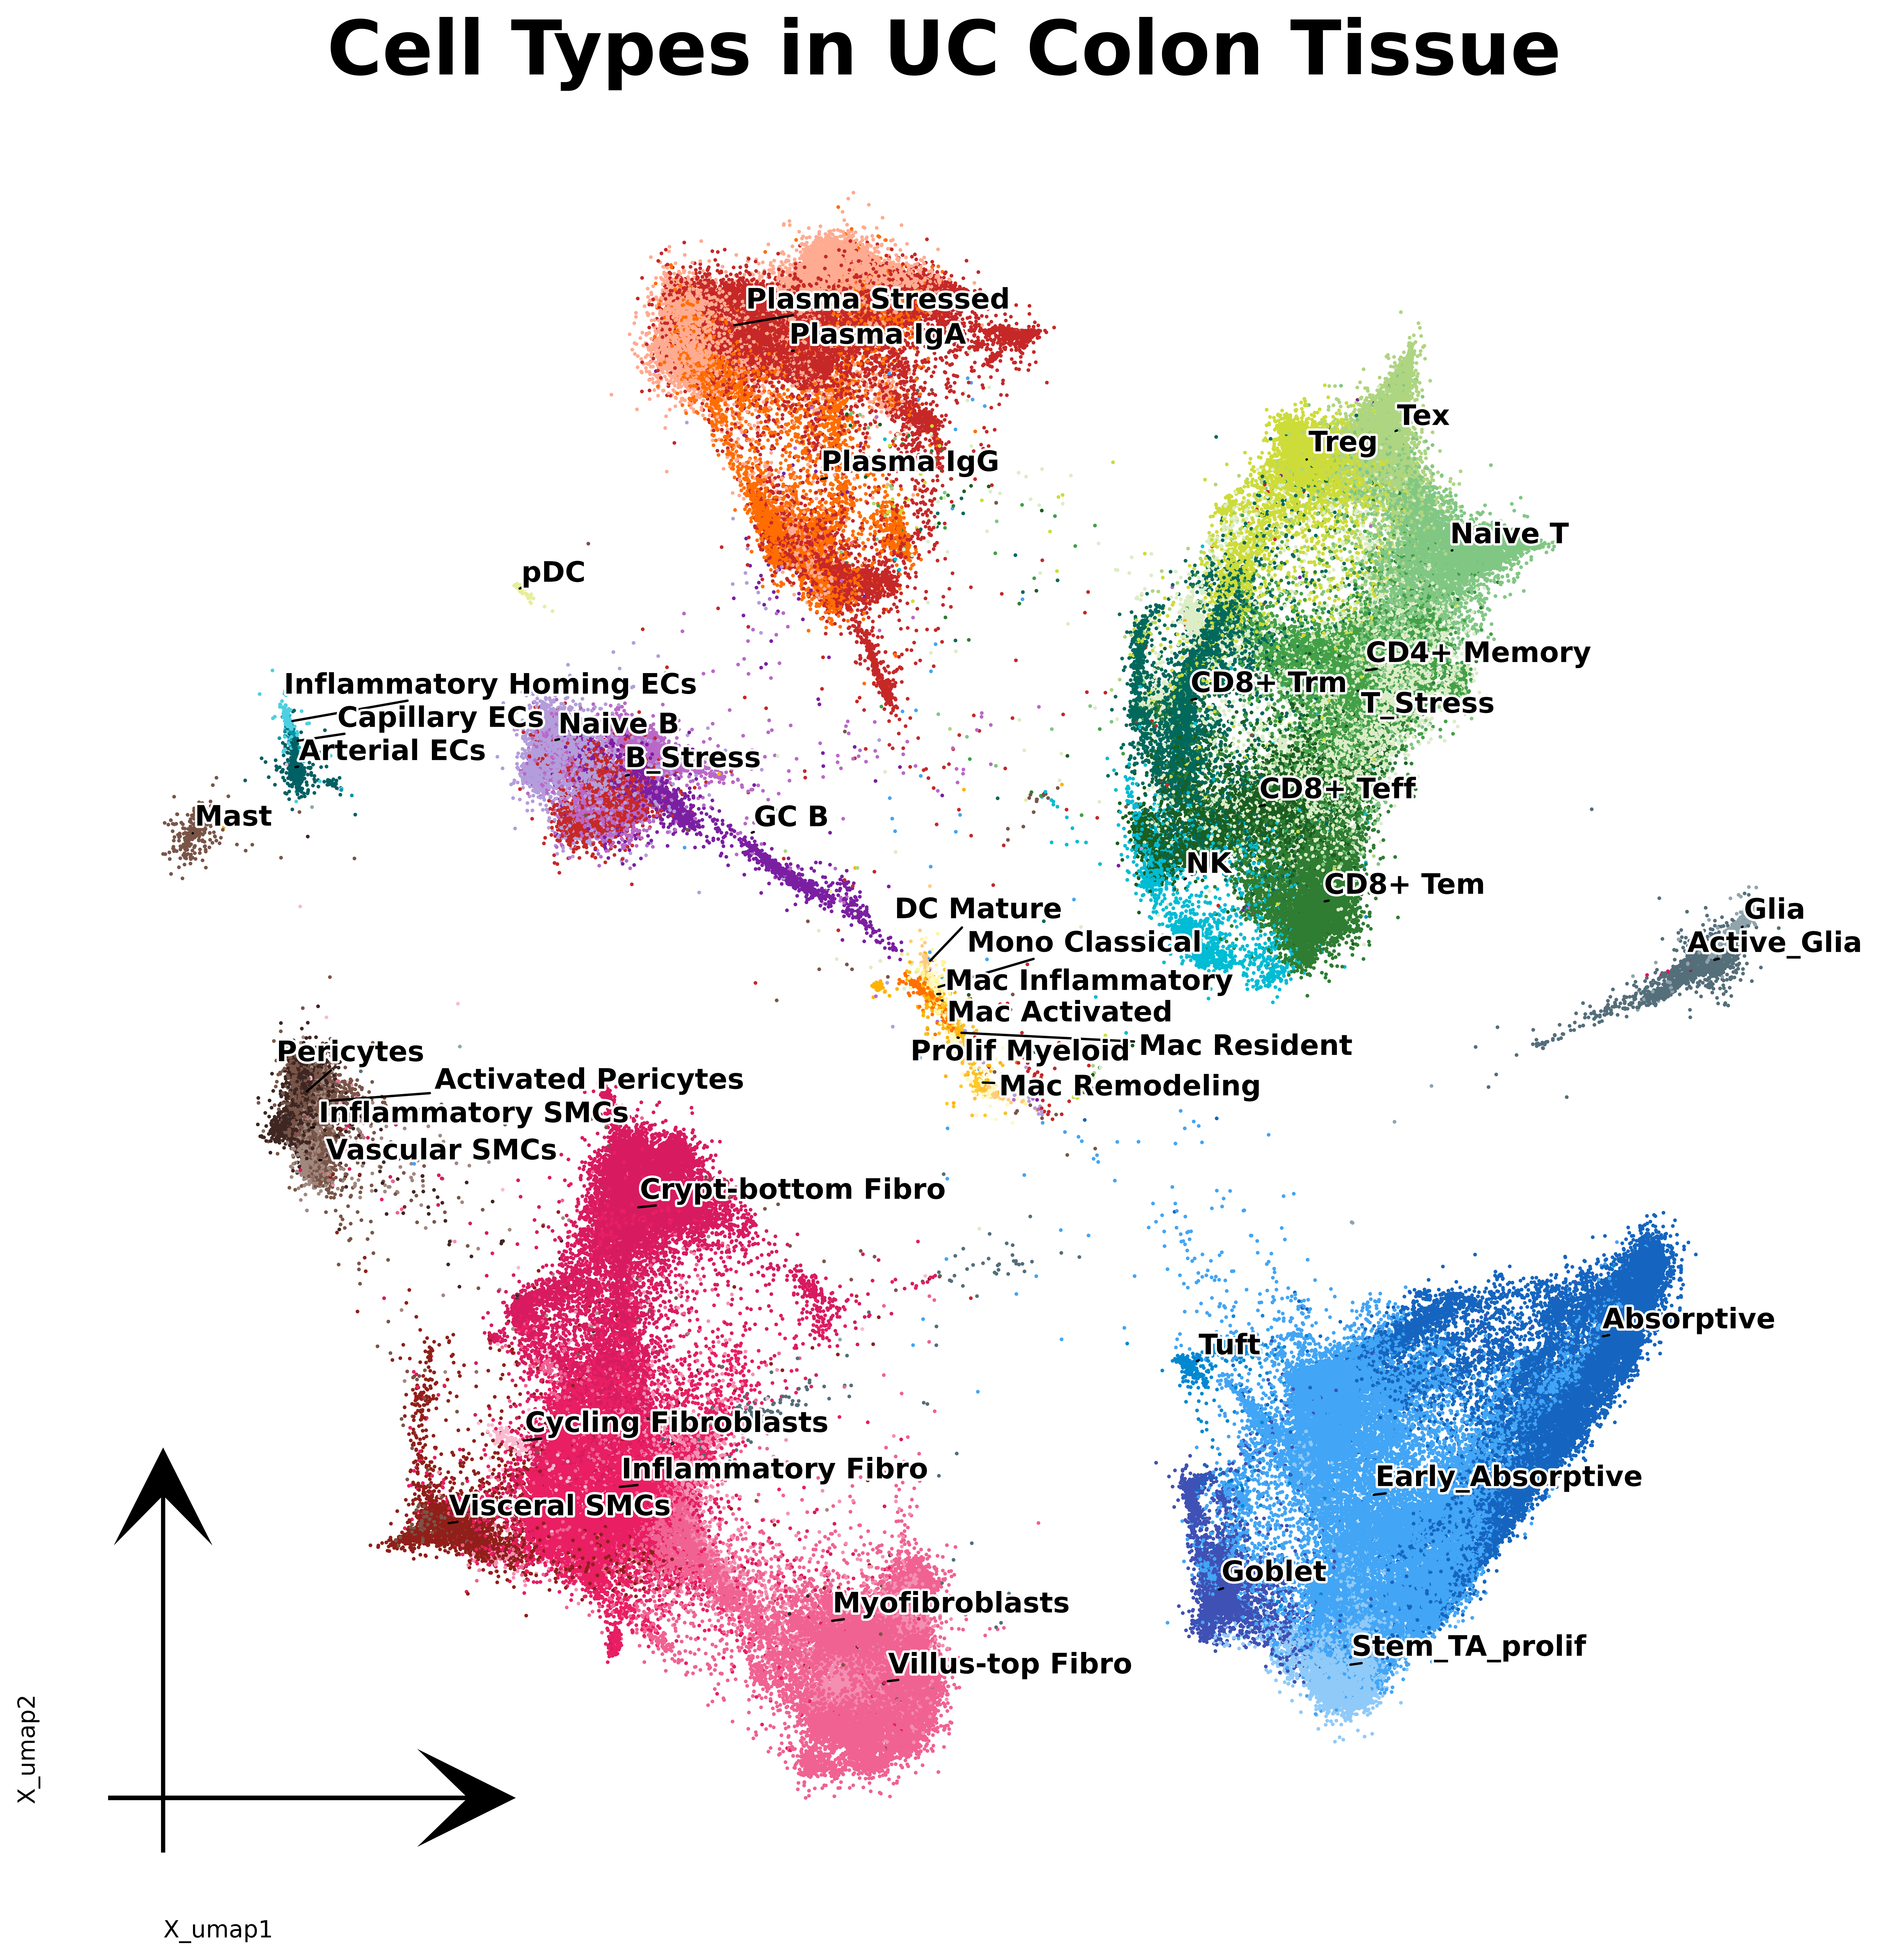

In [51]:
from matplotlib import patheffects
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14,14), dpi=600)

ov.pl.embedding(adata,
                basis='X_umap',
                color=['L3'],
                palette=celltype_color,
                show=False, 
                legend_loc=None, 
                add_outline=False, 
                frameon='small',
                legend_fontoutline=2,
                ax=ax,
                size=10)

ov.pl.embedding_adjust(
    adata,
    groupby='L3',
    exclude=("OL",),  
    basis='X_umap',
    ax=ax,
    adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
    text_kwargs=dict(fontsize=12 ,weight='bold',
                     path_effects=[patheffects.withStroke(linewidth=2, foreground='w')] ),
)

ax.set_title("Cell Types in UC Colon Tissue", fontsize=32, fontweight='bold',pad=15)

plt.savefig("/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/Merge/figs/UC_Colon_CellTypes.png", dpi=600, bbox_inches='tight')
plt.show()